In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU: []


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
dataset_path = "/content/drive/MyDrive/parking dataset"

print(os.listdir(dataset_path))

['empty', 'occupied']


In [4]:
import os

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        images = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

        print(folder, ":", len(images))

empty : 908
occupied : 818


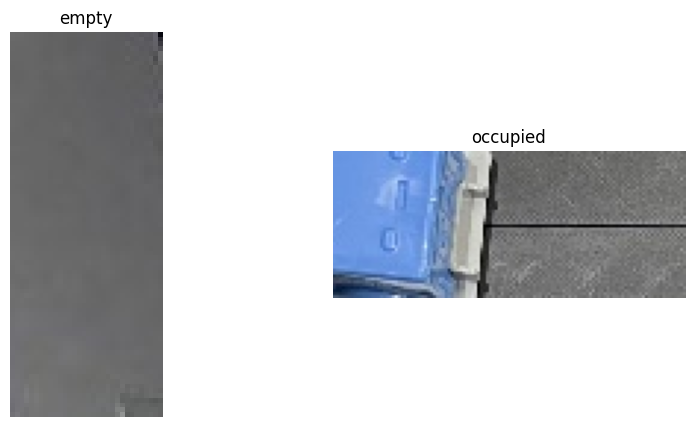

In [5]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

classes = ["empty", "occupied"]

plt.figure(figsize=(10, 5))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    image_name = random.choice(image_files)
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(1, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.show()

Train Test Split + data augumentation

In [6]:
import shutil
import os

parking_path = os.path.join(dataset_path, "images")

if os.path.exists(parking_path):
    shutil.rmtree(parking_path)
    print("Parking folder removed.")

In [7]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)


In [8]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    subset="training",
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=16,
    class_mode="binary",
    subset="validation",
    shuffle=False
)



Found 1382 images belonging to 2 classes.
Found 344 images belonging to 2 classes.


In [9]:
print(train_generator.class_indices)

{'empty': 0, 'occupied': 1}


In [10]:
print("Training images:", train_generator.samples)
print("Validation images:", validation_generator.samples)

Training images: 1382
Validation images: 344


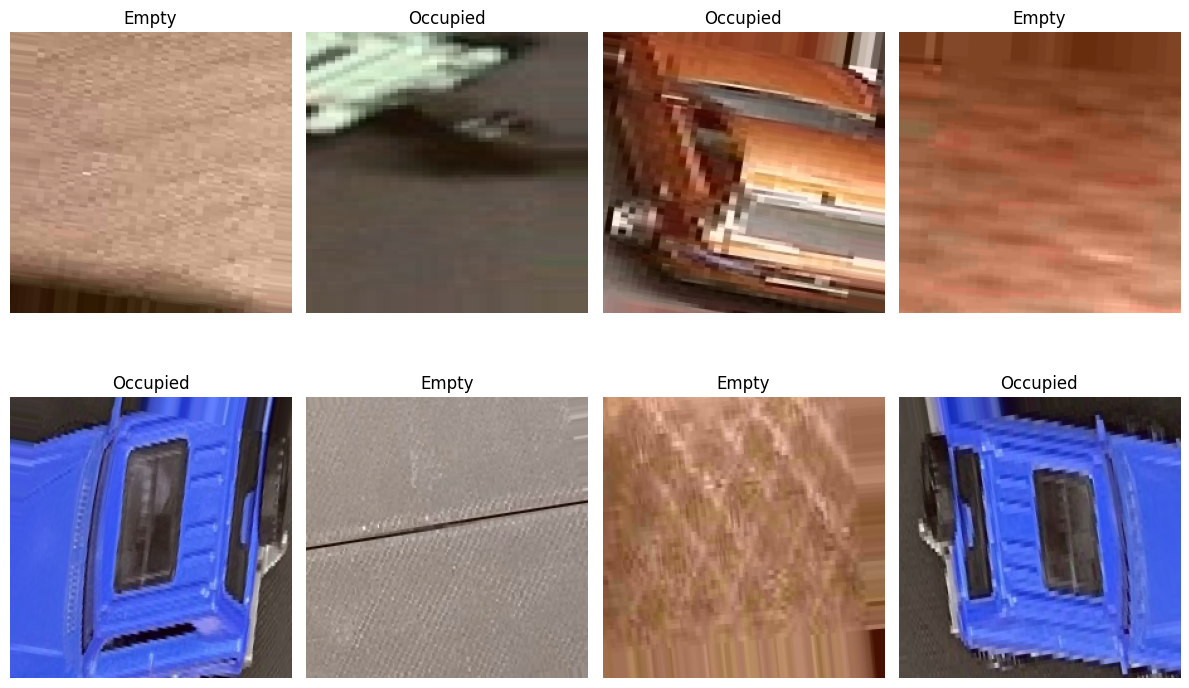

In [11]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(8):

    plt.subplot(2, 4, i + 1)

    # ResNet preprocessing changes pixel values,
    # so normalize only for visualization
    img = images[i]
    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)

    if labels[i] == 0:
        title = "Empty"
    else:
        title = "Occupied"

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [13]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.4)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),

    ModelCheckpoint(
        "/content/best_resnet50.keras",
        monitor="val_loss",
        save_best_only=True
    )
]

In [16]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 499s 6s/step - accuracy: 0.9703 - loss: 0.0663 - val_accuracy: 1.0000 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 2/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 368s 4s/step - accuracy: 0.9920 - loss: 0.0248 - val_accuracy: 1.0000 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 3/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 364s 4s/step - accuracy: 0.9935 - loss: 0.0213 - val_accuracy: 0.9971 - val_loss: 0.0051 - learning_rate: 0.0010
Epoch 4/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - accuracy: 0.9949 - loss: 0.0112 - val_accuracy: 0.9971 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 375s 4s/step - accuracy: 0.9935 - loss: 0.0181 - val_accuracy: 1.0000 - val_loss: 0.0027 - learning_rate: 0.0010
Epoch 6/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - accuracy: 0.9928 - loss: 0.0170 - val_accuracy: 0.9942 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 7/10
87/87 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step - accuracy: 0.9964 - loss: 0.0125 - val_acc

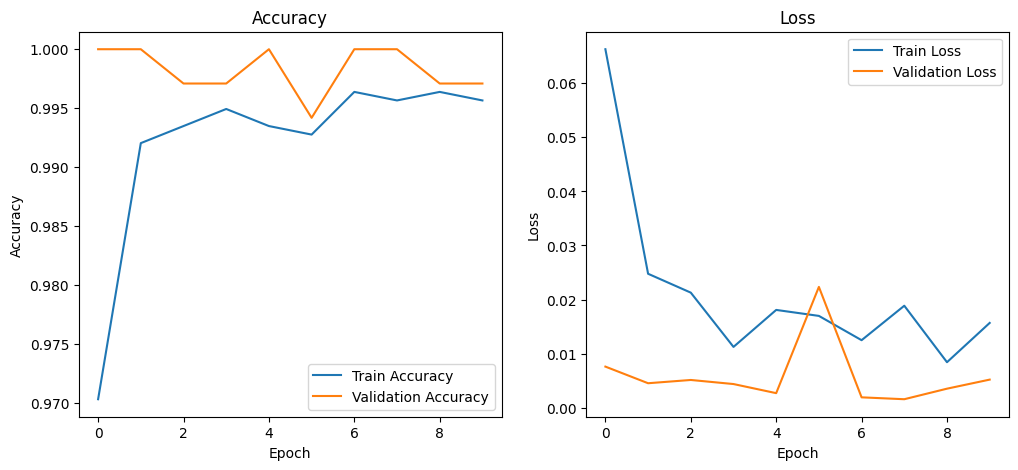

In [17]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [18]:
val_loss, val_accuracy = model.evaluate(validation_generator)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 70s 3s/step - accuracy: 1.0000 - loss: 0.0016
Validation Loss: 0.0015630789566785097
Validation Accuracy: 1.0


In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

validation_generator.reset()

predictions = model.predict(validation_generator)

predicted_classes = (predictions > 0.5).astype(int).flatten()
true_classes = validation_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["Empty", "Occupied"]
))

22/22 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step
[[181   0]
 [  0 163]]
              precision    recall  f1-score   support

       Empty       1.00      1.00      1.00       181
    Occupied       1.00      1.00      1.00       163

    accuracy                           1.00       344
   macro avg       1.00      1.00      1.00       344
weighted avg       1.00      1.00      1.00       344



test on new image

In [20]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np

def predict_parking(image_path):

    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    img_array = img_to_array(img)

    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    prediction = model.predict(img_array, verbose=0)[0][0]

    print("Raw prediction:", prediction)

    if prediction >= 0.5:
        print("Prediction: OCCUPIED")
    else:
        print("Prediction: EMPTY")

In [21]:
predict_parking("/Screenshot 2026-10-06 at 11.03.57 AM.png")

FileNotFoundError: [Errno 2] No such file or directory: '/Screenshot 2026-10-06 at 11.03.57\u202fAM.png'

Savind model

In [22]:
model.save("/content/drive/MyDrive/parking dataset/resnet50_parking.keras")

In [29]:
import os

model_path = "/content/drive/MyDrive/parking dataset/resnet50_parking.keras"

print(os.path.exists(model_path))

True


In [23]:
class_names = {
    0: "Empty",
    1: "Occupied"
}

In [25]:
from sklearn.metrics import classification_report, confusion_matrix

# Using the correct variable names defined in your workspace:
# true_classes and predicted_classes
print("Confusion Matrix:")
print(confusion_matrix(true_classes, predicted_classes))

print("\nClassification Report:")
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=["Empty", "Occupied"]
))

Confusion Matrix:
[[181   0]
 [  0 163]]

Classification Report:
              precision    recall  f1-score   support

       Empty       1.00      1.00      1.00       181
    Occupied       1.00      1.00      1.00       163

    accuracy                           1.00       344
   macro avg       1.00      1.00      1.00       344
weighted avg       1.00      1.00      1.00       344



# prediction function

In [26]:
def predict_parking(image_path):

    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)

    probability = model.predict(img, verbose=0)[0][0]

    if probability >= 0.5:
        result = "Occupied"
        confidence = probability
    else:
        result = "Empty"
        confidence = 1 - probability

    return result, confidence

In [28]:
result, confidence = predict_parking(
    "/content/9.png"
)

print("Prediction:", result)
print("Confidence:", confidence * 100, "%")

Prediction: Occupied
Confidence: 100.0 %


In [30]:
import tensorflow as tf
import numpy as np
import cv2
import os

from tensorflow.keras.models import load_model
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input

model_path = "/content/drive/MyDrive/parking dataset/resnet50_parking.keras"

model = load_model(model_path)

print("Model loaded successfully")

Model loaded successfully


In [32]:
parking_image_path = "/content/parkingarea.png"

image = cv2.imread(parking_image_path)

print(image.shape)

(417, 626, 3)


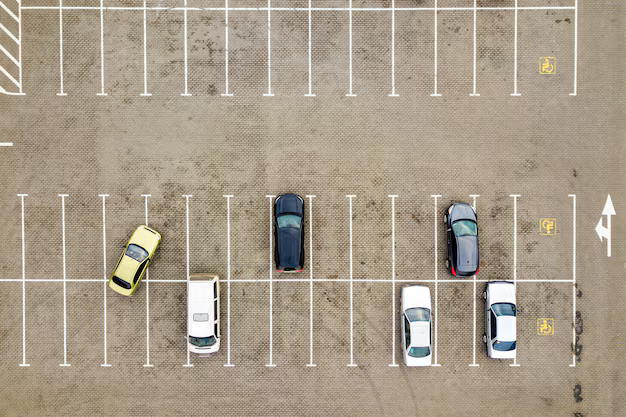

In [33]:
from google.colab.patches import cv2_imshow

cv2_imshow(image)

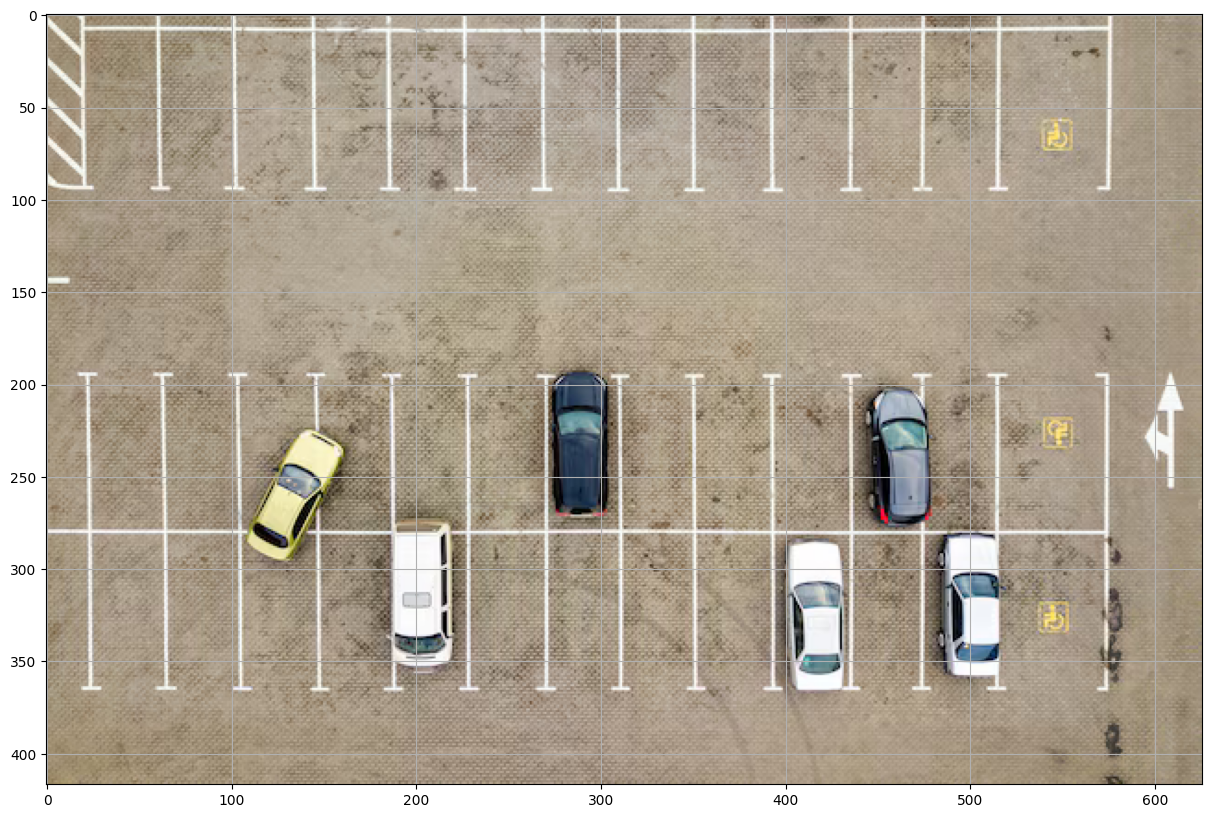

In [34]:
import matplotlib.pyplot as plt

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))
plt.imshow(image_rgb)
plt.axis("on")
plt.grid()
plt.show()

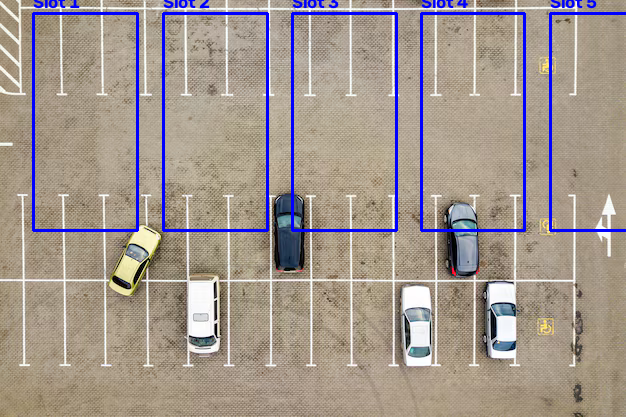

In [39]:
image_copy = image.copy()

# Define the coordinates [x1, y1, x2, y2] for each parking slot bounding box
# (Adjust these coordinates if needed to perfectly fit your parking slots)
parking_spots = [
    # Top Row (Spots 1–8)
    (21, 8, 83, 92),
    (98, 8, 160, 92),
    (175, 8, 238, 92),
    (252, 8, 314, 92),
    (329, 8, 391, 92),
    (406, 8, 468, 92),
    (484, 8, 545, 92),
   ( 561, 8, 600, 92),

    # Bottom Row (Spots 9–16)
    (21, 186, 83, 351),
    (98, 186, 160, 351),
    (175, 186, 238, 351),
    (252, 186, 314, 351),
    (329, 186, 391, 351),
    (406, 186, 468, 351),
    (484, 186, 545, 351),
    (561, 186, 600, 351)
]

for i, (x1, y1, x2, y2) in enumerate(parking_slots):

    cv2.rectangle(
        image_copy,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    cv2.putText(
        image_copy,
        f"Slot {i+1}",
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

cv2_imshow(image_copy)

Visulalize coordinates

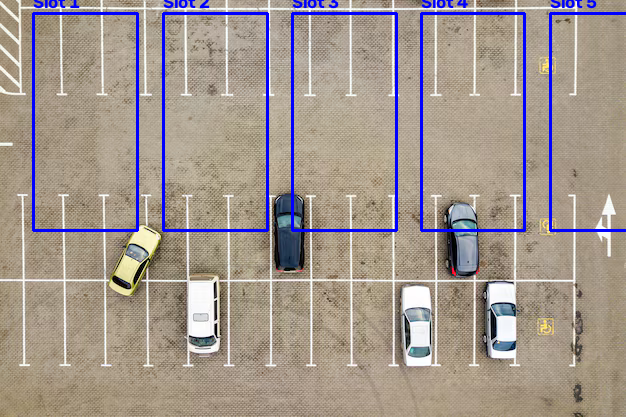

In [40]:
image_copy = image.copy()

for i, (x1, y1, x2, y2) in enumerate(parking_slots):

    cv2.rectangle(
        image_copy,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

    cv2.putText(
        image_copy,
        f"Slot {i+1}",
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (255, 0, 0),
        2
    )

cv2_imshow(image_copy)

Create the ResNet50 prediction function

In [41]:
def predict_slot(slot_image):

    # Resize
    slot_image = cv2.resize(
        slot_image,
        (224, 224)
    )

    # Convert BGR → RGB
    slot_image = cv2.cvtColor(
        slot_image,
        cv2.COLOR_BGR2RGB
    )

    # Convert to array
    slot_image = img_to_array(slot_image)

    # Add batch dimension
    slot_image = np.expand_dims(
        slot_image,
        axis=0
    )

    # ResNet50 preprocessing
    slot_image = preprocess_input(slot_image)

    # Prediction
    prediction = model.predict(
        slot_image,
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        label = "Occupied"
        confidence = prediction
    else:
        label = "Empty"
        confidence = 1 - prediction

    return label, confidence

Testing one

In [43]:
import os
from tensorflow.keras.models import load_model

# Ensure model is loaded globally
model_path = "/content/drive/MyDrive/parking dataset/resnet50_parking.keras"
if 'model' not in globals():
    if os.path.exists(model_path):
        model = load_model(model_path)
        print("Model loaded successfully!")
    else:
        raise FileNotFoundError(f"Model file not found at {model_path}")

x1, y1, x2, y2 = parking_slots[1]

slot = image[y1:y2, x1:x2]

label, confidence = predict_slot(slot)

print("Prediction:", label)
print("Confidence:", confidence * 100)

Model loaded successfully!
Prediction: Occupied
Confidence: 99.99992


Test on every

In [44]:
results = []

empty_count = 0
occupied_count = 0

# Corrected coordinates fitting within width=626 and height=417
parking_spots = [
    # Top Row (Spots 1–8)
    (21, 8, 83, 92),
    (98, 8, 160, 92),
    (175, 8, 238, 92),
    (252, 8, 314, 92),
    (329, 8, 391, 92),
    (406, 8, 468, 92),
    (484, 8, 545, 92),
   ( 561, 8, 600, 92),

    # Bottom Row (Spots 9–16)
    (21, 186, 83, 351),
    (98, 186, 160, 351),
    (175, 186, 238, 351),
    (252, 186, 314, 351),
    (329, 186, 391, 351),
    (406, 186, 468, 351),
    (484, 186, 545, 351),
    (561, 186, 600, 351)
]

for i, (x1, y1, x2, y2) in enumerate(parking_slots):

    # Crop parking space
    slot = image[y1:y2, x1:x2]

    # Check if the cropped slot is empty to prevent resize errors
    if slot.size == 0:
        print(f"Slot {i+1}: Crop is empty! Check coordinates: [{x1}, {y1}, {x2}, {y2}]")
        continue

    # Predict
    label, confidence = predict_slot(slot)

    # Store result
    results.append({
        "slot": i + 1,
        "label": label,
        "confidence": confidence
    })

    # Count
    if label == "Empty":
        empty_count += 1
    else:
        occupied_count += 1

    print(
        f"Slot {i+1}: {label} "
        f"({confidence * 100:.2f}%)"
    )

print(f"\nTotal Slots: {len(parking_slots)} | Occupied: {occupied_count} | Empty: {empty_count}")

Slot 1: Occupied (100.00%)
Slot 2: Occupied (100.00%)
Slot 3: Occupied (100.00%)
Slot 4: Occupied (100.00%)
Slot 5: Empty (85.16%)
Slot 6: Crop is empty! Check coordinates: [679, 13, 782, 230]
Slot 7: Crop is empty! Check coordinates: [809, 13, 911, 230]
Slot 8: Crop is empty! Check coordinates: [938, 13, 1000, 230]
Slot 9: Crop is empty! Check coordinates: [33, 465, 137, 878]
Slot 10: Crop is empty! Check coordinates: [163, 465, 267, 878]
Slot 11: Crop is empty! Check coordinates: [292, 465, 396, 878]
Slot 12: Crop is empty! Check coordinates: [421, 465, 524, 878]
Slot 13: Crop is empty! Check coordinates: [550, 465, 653, 878]
Slot 14: Crop is empty! Check coordinates: [679, 465, 782, 878]
Slot 15: Crop is empty! Check coordinates: [809, 465, 911, 878]
Slot 16: Crop is empty! Check coordinates: [938, 465, 1000, 878]

Total Slots: 16 | Occupied: 4 | Empty: 1


In [45]:
print("--------------------------------")
print("Total parking spaces:", len(parking_slots))
print("Empty spaces:", empty_count)
print("Occupied spaces:", occupied_count)
print("--------------------------------")

--------------------------------
Total parking spaces: 16
Empty spaces: 1
Occupied spaces: 4
--------------------------------


In [47]:
output_image = image.copy()

for i, (x1, y1, x2, y2) in enumerate(parking_slots):

    slot = image[y1:y2, x1:x2]

    # Prevent empty crop resize crash
    if slot.size == 0:
        continue

    label, confidence = predict_slot(slot)

    if label == "Empty":
        color = (0, 255, 0)
    else:
        color = (0, 0, 255)

    # Draw rectangle
    cv2.rectangle(
        output_image,
        (x1, y1),
        (x2, y2),
        color,
        3
    )

    # Write label
    cv2.putText(
        output_image,
        f"{i+1}: {label}",
        (x1, y1 - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )

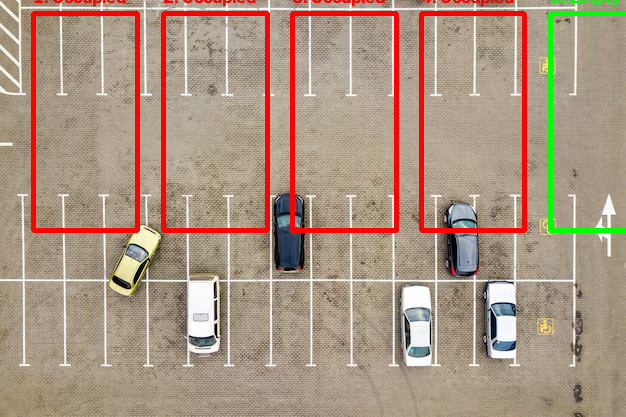

In [48]:
cv2_imshow(output_image)

array([[[120, 143, 158],
        [126, 149, 164],
        [128, 154, 171],
        ...,
        [127, 149, 161],
        [129, 151, 163],
        [130, 152, 164]],

       [[188, 211, 226],
        [134, 157, 172],
        [111, 137, 154],
        ...,
        [122, 144, 156],
        [134, 156, 168],
        [134, 156, 168]],

       [[237, 248, 246],
        [219, 230, 228],
        [133, 155, 167],
        ...,
        [129, 146, 159],
        [140, 159, 172],
        [140, 159, 172]],

       ...,

       [[ 91, 127, 145],
        [ 94, 130, 148],
        [ 97, 133, 151],
        ...,
        [109, 132, 147],
        [134, 153, 166],
        [134, 153, 166]],

       [[ 93, 129, 147],
        [104, 140, 158],
        [103, 139, 157],
        ...,
        [119, 142, 157],
        [120, 139, 152],
        [120, 139, 152]],

       [[ 95, 131, 149],
        [ 97, 133, 151],
        [ 97, 133, 151],
        ...,
        [116, 143, 157],
        [126, 142, 155],
        [126, 142, 155]]], dtype=uint8)
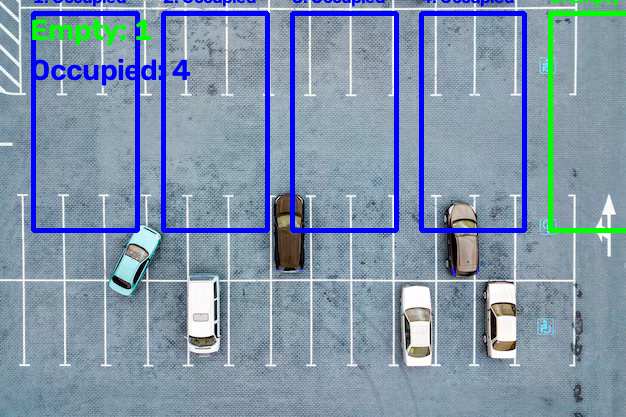

In [49]:
cv2.putText(
    output_image,
    f"Empty: {empty_count}",
    (30, 40),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    2
)

cv2.putText(
    output_image,
    f"Occupied: {occupied_count}",
    (30, 80),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 0, 255),
    2
)

In [50]:
output_path = "/content/drive/MyDrive/parking dataset/parking_result.jpg"

cv2.imwrite(
    output_path,
    output_image
)

print("Saved:", output_path)

Saved: /content/drive/MyDrive/parking dataset/parking_result.jpg


In [51]:
def analyze_parking_lot(image_path, parking_slots):

    image = cv2.imread(image_path)

    output_image = image.copy()

    empty_count = 0
    occupied_count = 0

    results = []

    for i, (x1, y1, x2, y2) in enumerate(parking_slots):

        # Crop slot
        slot = image[y1:y2, x1:x2]

        # Predict
        label, confidence = predict_slot(slot)

        # Store
        results.append({
            "slot": i + 1,
            "prediction": label,
            "confidence": confidence
        })

        # Count
        if label == "Empty":
            empty_count += 1
            color = (0, 255, 0)
        else:
            occupied_count += 1
            color = (0, 0, 255)

        # Draw
        cv2.rectangle(
            output_image,
            (x1, y1),
            (x2, y2),
            color,
            3
        )

        cv2.putText(
            output_image,
            f"{i+1}: {label}",
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    # Summary
    cv2.putText(
        output_image,
        f"Empty: {empty_count}",
        (30, 40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 255, 0),
        2
    )

    cv2.putText(
        output_image,
        f"Occupied: {occupied_count}",
        (30, 80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        2
    )

    return output_image, results

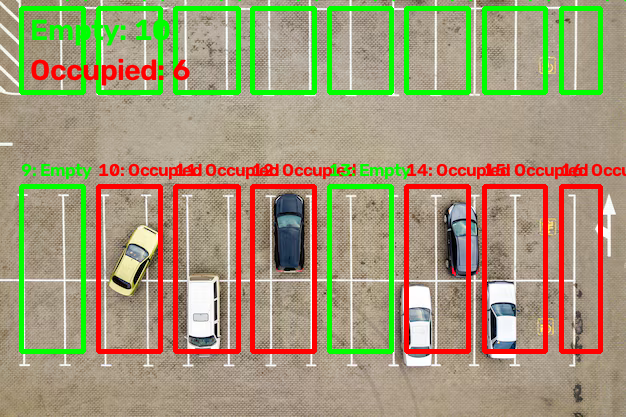

In [53]:
# Use the corrected coordinates variable 'parking_spots' to match the 626x417 image dimensions
result_image, results = analyze_parking_lot(
    parking_image_path,
    parking_spots
)

cv2_imshow(result_image)

In [54]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/parking dataset/resnet50_parking.keras"

resnet_model = load_model(model_path)

print("Model loaded successfully!")

Model loaded successfully!


In [55]:
parking_spots = [
    # Top Row (Spots 1–8)
    (21, 8, 83, 92),
    (98, 8, 160, 92),
    (175, 8, 238, 92),
    (252, 8, 314, 92),
    (329, 8, 391, 92),
    (406, 8, 468, 92),
    (484, 8, 545, 92),
   ( 561, 8, 600, 92),

    # Bottom Row (Spots 9–16)
    (21, 186, 83, 351),
    (98, 186, 160, 351),
    (175, 186, 238, 351),
    (252, 186, 314, 351),
    (329, 186, 391, 351),
    (406, 186, 468, 351),
    (484, 186, 545, 351),
    (561, 186, 600, 351)
]

In [56]:
import cv2
import numpy as np

from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input


def predict_slot(model, slot):

    slot = cv2.resize(slot, (224, 224))

    slot = cv2.cvtColor(slot, cv2.COLOR_BGR2RGB)

    slot = img_to_array(slot)

    slot = np.expand_dims(slot, axis=0)

    slot = preprocess_input(slot)

    prediction = model.predict(
        slot,
        verbose=0
    )[0][0]

    if prediction >= 0.5:
        return "Occupied", float(prediction)
    else:
        return "Empty", float(1 - prediction)

In [57]:
def analyze_parking(image, model, parking_slots):

    output = image.copy()

    empty_count = 0
    occupied_count = 0

    results = []

    for i, (x1, y1, x2, y2) in enumerate(parking_slots):

        # Crop the parking slot
        slot = image[y1:y2, x1:x2]

        # Predict
        status, confidence = predict_slot(model, slot)

        # Count
        if status == "Empty":
            empty_count += 1
            color = (0, 255, 0)

        else:
            occupied_count += 1
            color = (0, 0, 255)

        # Draw rectangle
        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            color,
            2
        )

        # Draw slot label
        cv2.putText(
            output,
            f"S{i+1}: {status}",
            (x1, max(y1 - 5, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            color,
            2
        )

        results.append({
            "slot": i + 1,
            "status": status,
            "confidence": confidence
        })

    total_slots = len(parking_slots)

    occupancy_rate = (
        occupied_count / total_slots * 100
        if total_slots > 0 else 0
    )

    return (
        output,
        results,
        empty_count,
        occupied_count,
        occupancy_rate
    )

In [59]:
image_path = "/content/parkingarea.png"

image = cv2.imread(image_path)

print(image.shape)

(417, 626, 3)


In [61]:
output, results, empty_count, occupied_count, occupancy_rate = analyze_parking(
    image,
    resnet_model,
    parking_spots
)

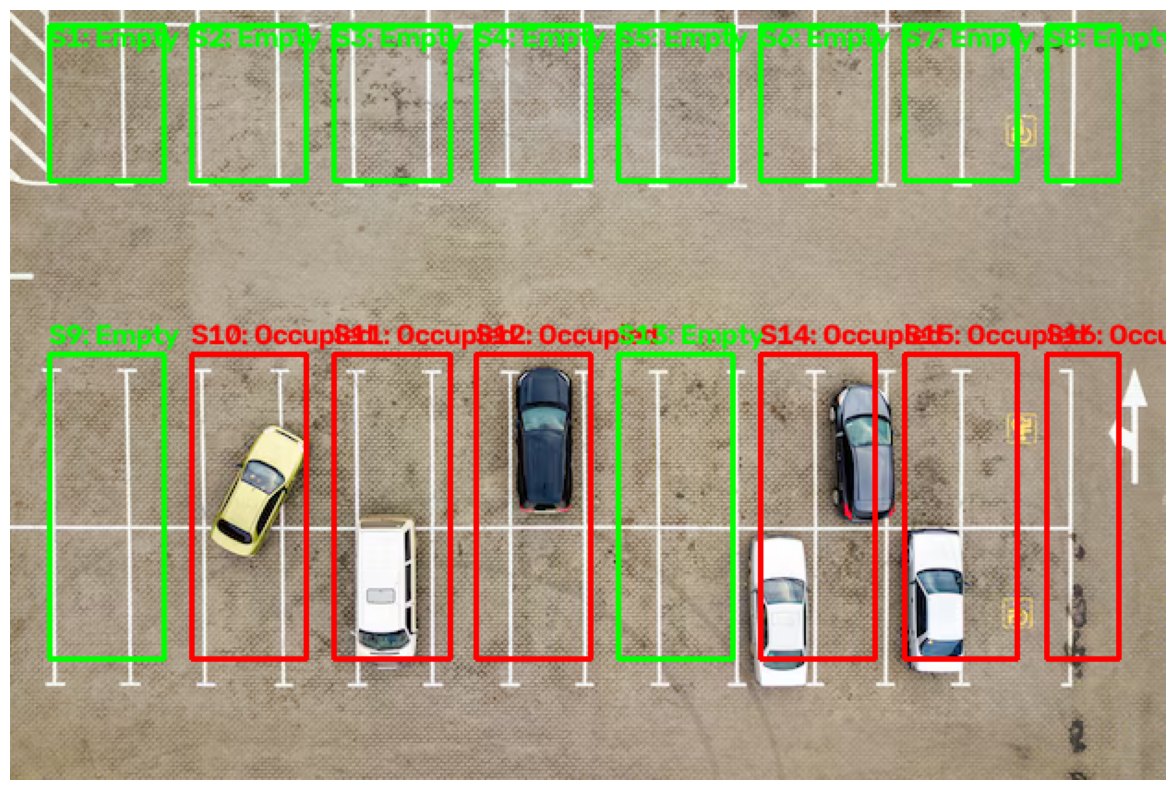

In [62]:
import matplotlib.pyplot as plt

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))
plt.imshow(output_rgb)
plt.axis("off")
plt.show()

In [63]:
print("Total Slots:", len(parking_slots))
print("Empty Slots:", empty_count)
print("Occupied Slots:", occupied_count)
print(f"Occupancy Rate: {occupancy_rate:.2f}%")

Total Slots: 16
Empty Slots: 10
Occupied Slots: 6
Occupancy Rate: 37.50%
